 # Lab 1: Cross-Entropy Method (CEM) for CartPole



 ## Introduction

 In this lab, we will implement the Cross-Entropy Method (CEM) algorithm to solve the CartPole-v1 environment. CEM is a simple yet effective policy search method that iteratively improves a policy by sampling from a distribution and selecting elite samples.



 ## Student Information

 **Name:** Kevin Cotellesso

 **Date:** 3-12-2026



 ---

 ## Part 1: Setup and Environment Testing

 Let's start by importing the necessary libraries and creating the CartPole environment.

In [2]:
import numpy as np
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display

# Create environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

total_reward = 0.0
total_steps = 0
obs, info = env.reset()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Initial observation: {obs}")


Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.0262642   0.00729001 -0.01409904 -0.03187358]


 ### Random Agent Test

 Let's test the environment with a random agent to see how it performs.

In [3]:
while True:
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward
    plt.imshow(env.render())
    display.display(plt.gcf())    
    display.clear_output(wait=True)
    plt.close()

    if done or truncated:
        break

print(f"Random agent - Total reward: {total_reward}, Total steps: {total_steps}")



Random agent - Total reward: 10.0, Total steps: 0


 ---

 ## Part 2: Linear Policy Implementation



 We'll implement a simple linear policy that maps observations to actions using a weight matrix W and bias vector b.

In [4]:
class LinearPolicy(object):
    def __init__(self, theta, ob_space, ac_space):
        assert len(theta) == (ob_space + 1) * ac_space
        self.W = theta[0:ob_space*ac_space].reshape(ob_space, ac_space)
        self.b = theta[ob_space*ac_space:None].reshape(1, ac_space)

    def act(self, obs):
        y = obs.dot(self.W) + self.b
        a = y.argmax()
        return a


# Test the policy
ob_space = env.observation_space.shape[0]
ac_space = env.action_space.n
n_theta = (ob_space + 1) * ac_space
print(f"Policy parameter size: {n_theta}")

def run_episode(policy, env, num_steps, render=False):
    total_rew = 0
    ob, info = env.reset()
    for t in range(num_steps):
        a = policy.act(ob)
        ob, reward, done, truncated, info = env.step(a)
        total_rew += reward
        if done or truncated:
            break
    return total_rew


theta_mean = np.zeros(n_theta)
theta_std = np.ones(n_theta)

reward_list = []

# CEM hyperparameters
n_iterations = 50  # Number of CEM iterations
n_samples = 25     # Number of policy samples per iteration
n_elite = 5        # Number of elite samples to keep

print("Starting CEM training...")
print(f"Iterations: {n_iterations}, Samples: {n_samples}, Elite: {n_elite}")
print("-" * 60)

for itr in range(n_iterations):
    # Sample policies from current distribution
    thetas = np.random.multivariate_normal(
        mean=theta_mean,
        cov=np.diag(np.array(theta_std)**2),
        size=n_samples
    )

    rewards = []
    for theta in thetas:
        policy = LinearPolicy(theta, ob_space, ac_space)
        r = run_episode(policy, env, 500)
        rewards.append(r)

    rewards = np.array(rewards)
    
    # Get elite parameters
    elite_inds = rewards.argsort()[-n_elite:]
    elite_thetas = thetas[elite_inds]

    # Update theta_mean, theta_std
    theta_mean = elite_thetas.mean(axis=0)
    theta_std = elite_thetas.std(axis=0)
    
    # Log progress
    print(f"[Iteration {itr:2d}] mean: {np.mean(rewards):5.1f} | max: {np.max(rewards):5.1f} | min: {np.min(rewards):5.1f}")
    reward_list.append(np.mean(rewards))

print("-" * 60)
print("Training complete!")

env.close()


Policy parameter size: 10
Starting CEM training...
Iterations: 50, Samples: 25, Elite: 5
------------------------------------------------------------
[Iteration  0] mean:  16.7 | max:  85.0 | min:   8.0
[Iteration  1] mean:  66.4 | max: 500.0 | min:   8.0
[Iteration  2] mean:  56.9 | max: 267.0 | min:  10.0
[Iteration  3] mean: 168.0 | max: 500.0 | min:  35.0
[Iteration  4] mean: 276.0 | max: 500.0 | min:   9.0
[Iteration  5] mean: 367.9 | max: 500.0 | min:  10.0
[Iteration  6] mean: 465.6 | max: 500.0 | min: 222.0
[Iteration  7] mean: 462.1 | max: 500.0 | min: 136.0
[Iteration  8] mean: 446.1 | max: 500.0 | min:  26.0
[Iteration  9] mean: 500.0 | max: 500.0 | min: 500.0
[Iteration 10] mean: 500.0 | max: 500.0 | min: 500.0
[Iteration 11] mean: 500.0 | max: 500.0 | min: 500.0
[Iteration 12] mean: 500.0 | max: 500.0 | min: 500.0
[Iteration 13] mean: 500.0 | max: 500.0 | min: 500.0
[Iteration 14] mean: 500.0 | max: 500.0 | min: 500.0
[Iteration 15] mean: 500.0 | max: 500.0 | min: 500.0
[I

 ---

 ## Results Analysis - Discrete

 *What are the cons and pros of CEM for RL?*  
   
 **Pros:** Models with no analytical gradient can be used. Also, since CEM is an exploratory genetic algorithm, the model is less likely to fall into a local minimum and is less sensitive to initial weights.  
   
 **Cons:** It's slow and expensive, since you must evaluate the model in the environment many thousands of times. If the model contains many parameters, it is unlikely that this probabilistic approach will randomly stumble upon the perfect combination of parameters, leading to poor convergence. A good use of this genetic algorithm could be to find reasonable initial values to start a gradient backpropgagation.
  

Picture of the learning curve of CEM on `CartPole-V1`:

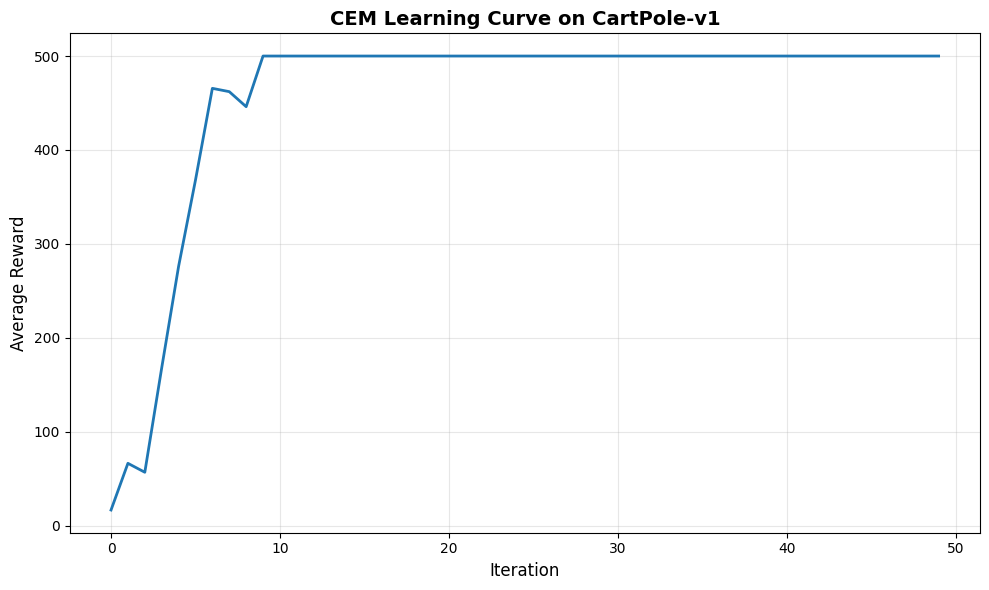

Initial average reward: 16.68
Final average reward: 500.00
Best average reward: 500.00
Improvement: 483.32


In [5]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(reward_list, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('CEM Learning Curve on CartPole-v1', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Initial average reward: {reward_list[0]:.2f}")
print(f"Final average reward: {reward_list[-1]:.2f}")
print(f"Best average reward: {max(reward_list):.2f}")
print(f"Improvement: {reward_list[-1] - reward_list[0]:.2f}")





 ---

 ## Save Results



 Save the results to a CSV file for later analysis.

In [6]:
df = pd.DataFrame({"reward": reward_list})
df.to_csv("Linear_CEM.csv", index=False, header=True)

env.close()

 ---

 ## Part 3: Linear Policy... but continuous!!

Use the same linear policy as in Part 3 but with a continuous output.  
To do this we need the pendulum environment.

In [7]:
# Create pendulum environment
env2 = gym.make("Pendulum-v1", render_mode="rgb_array")

total_reward = 0.0
total_steps = 0
obs, info = env2.reset()

print(f"Observation space: {env2.observation_space}")
print(f"Action space: {env2.action_space}")
print(f"Initial observation: {obs}")


Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Initial observation: [-0.08214566 -0.99662036  0.5801165 ]


In [20]:
# Make us a nice juicy continuous policy
class LinearContPolicy(object):
    def __init__(self, theta, ob_space, ac_space):
        assert len(theta) == (ob_space + 1) * ac_space
        self.W = theta[0:ob_space*ac_space].reshape(ob_space, ac_space)
        self.b = theta[ob_space*ac_space:None].reshape(1, ac_space)

    def act(self, obs):
        self.W = np.squeeze(self.W)
        obs = np.squeeze(obs)
        y = obs.dot(self.W) + self.b
        # a = y.argmax() # Instead of taking action 0 or 1 based on max probability, 
        # we shall squash the output to (-2,2).
        # I don't actually know what this -2 to 2 represents physically, but it doesn't matter.
        # a = ((1/(1 + np.exp(-y))) * 4) - 2 # Modified sigmoid
        a = np.tanh(y)*2
        return a

In [21]:
# Get continuous env observation and action spaces
ob_space = env2.observation_space.shape[0]
ac_space = env2.action_space.shape[0]
n_theta = (ob_space + 1) * ac_space
print(f"Size of continuous action space: {ac_space}")
print(f"Size of obs space: {ob_space}")
print(f"Policy parameter size: {n_theta}")

Size of continuous action space: 1
Size of obs space: 3
Policy parameter size: 4


(3 params for weight, 1 for bias)

In [22]:
# Run Cross-Entropy Method (genetic algorithm) on pendulum env
theta_mean = np.zeros(n_theta)
theta_std = np.ones(n_theta)

reward_list = []

# CEM hyperparameters
n_iterations = 50  # Number of CEM iterations
n_samples = 25     # Number of policy samples per iteration
n_elite = 5        # Number of elite samples to keep

print("Starting CEM training...")
print(f"Iterations: {n_iterations}, Samples: {n_samples}, Elite: {n_elite}")
print("-" * 60)

for itr in range(n_iterations):
    # Sample policies from current distribution
    thetas = np.random.multivariate_normal(
        mean=theta_mean,
        cov=np.diag(np.array(theta_std)**2),
        size=n_samples
    )

    rewards = []
    for theta in thetas:
        policy = LinearContPolicy(theta, ob_space, ac_space)
        r = run_episode(policy, env2, 500)
        rewards.append(r)

    rewards = np.array(rewards)
    rewards = np.squeeze(rewards)

    # Get elite parameters
    elite_inds = rewards.argsort()[-n_elite:]
    elite_thetas = thetas[elite_inds]

    # Update theta_mean, theta_std
    theta_mean = elite_thetas.mean(axis=0)
    theta_std = elite_thetas.std(axis=0)
    
    # Log progress
    print(f"[Iteration {itr:2d}] mean: {np.mean(rewards):5.1f} | max: {np.max(rewards):5.1f} | min: {np.min(rewards):5.1f}")
    reward_list.append(np.mean(rewards))

print("-" * 60)
print("Training complete!")

env2.close()

Starting CEM training...
Iterations: 50, Samples: 25, Elite: 5
------------------------------------------------------------
[Iteration  0] mean: -1564.3 | max: -1081.4 | min: -1854.9
[Iteration  1] mean: -1478.9 | max: -948.6 | min: -1841.6
[Iteration  2] mean: -1428.2 | max: -961.1 | min: -1834.0
[Iteration  3] mean: -1380.7 | max: -901.4 | min: -1600.7
[Iteration  4] mean: -1283.9 | max: -971.2 | min: -1526.2
[Iteration  5] mean: -1277.1 | max: -903.0 | min: -1510.6
[Iteration  6] mean: -1324.6 | max: -940.8 | min: -1517.2
[Iteration  7] mean: -1273.1 | max: -962.3 | min: -1506.9
[Iteration  8] mean: -1271.8 | max: -873.9 | min: -1519.0
[Iteration  9] mean: -1235.9 | max: -941.4 | min: -1516.6
[Iteration 10] mean: -1243.5 | max: -917.5 | min: -1500.7
[Iteration 11] mean: -1291.2 | max: -820.7 | min: -1525.0
[Iteration 12] mean: -1285.3 | max: -834.3 | min: -1529.2
[Iteration 13] mean: -1282.6 | max: -847.4 | min: -1514.3
[Iteration 14] mean: -1203.1 | max: -828.1 | min: -1476.7
[Iter

 ## Results Analysis - Continuous

 Let's visualize the learning curve and analyze the results.



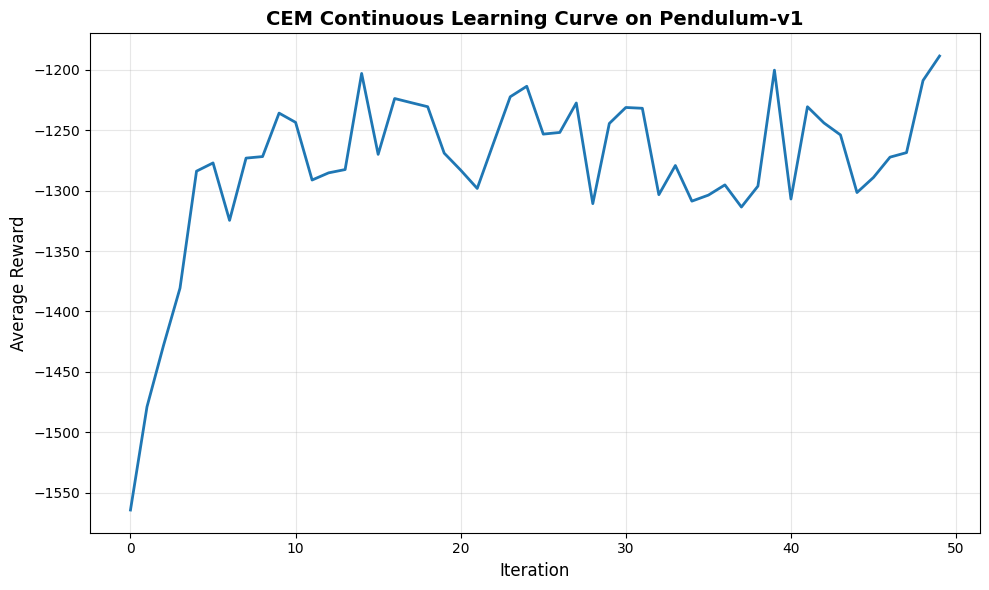

Initial average reward: -1564.29
Final average reward: -1188.65
Best average reward: -1188.65
Improvement: 375.64


In [23]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(reward_list, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('CEM Continuous Learning Curve on Pendulum-v1', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Initial average reward: {reward_list[0]:.2f}")
print(f"Final average reward: {reward_list[-1]:.2f}")
print(f"Best average reward: {max(reward_list):.2f}")
print(f"Improvement: {reward_list[-1] - reward_list[0]:.2f}")





Gee, that didn't do too hot...

 ## Save Results



 Save the results to a CSV file for later analysis.

In [24]:
df = pd.DataFrame({"reward": reward_list})
df.to_csv("Linear_CEM_Continuous.csv", index=False, header=True)

env.close()

 ---
## Part 4: Train a Silly "Neural Network" with a Genetic Algorithm

This one is kinda silly, but we may get better results!  
Thought process:
1. The point of adding more and more neural network layers is to allow estimation of a complex nonlinear function.
2. Adding more and more neural network layers adds more parameters, making it difficult for a genetic algorithm to converge.
3. This system (`Pendulum_v1`) is nonlinear because it is a **circle**.
4. Including **circular** functions in the model may account for the nonlinearities of this system without adding a huge number of parameters!

This network (`KeviNet`) is essentially a linear policy and a "circular" policy. The linear policy is the same as the linear policy in the previous section. The circular policy is identical, except it wraps $x$ within a cosine function:
$$input = cos(\omega*input + \phi)$$
where $\omega$ is some frequency and $\phi$ is some phase offset. Both are parameters to be trained, with the same dimensions as the input. Just basic physics 2 stuff.  

In [ ]:
class KeviNet:
    def __init__(self, input_dim, output_dim):
        # Normal densely connected layer
        self.Wn = np.random.randn(input_dim, output_dim) * 0.1
        self.bn = np.zeros(output_dim)

        # Weird silly circular cosine layer
        self.omega = np.random.randn(input_dim) * 2*np.pi # To multiply by input before cos
        self.phi = np.random.randn(input_dim) * 2*np.pi # Add to input*omega
        self.Wc = np.random.randn(input_dim, output_dim) * 0.1
        self.bc = np.zeros(output_dim)

        self.Wout = np.random.randn(output_dim, 2) * 0.1 # Combining the circular and linear stuff
        self.bout = np.zeros(output_dim)
        
        # How many theta?
        self.n_theta = self.Wn.size + self.bn.size + self.omega.size + self.phi.size + self.Wc.size + self.bc.size + self.Wout.size + self.bout.size
    
    def set_theta(self, theta):
        if(theta.size != self.n_theta):
            raise ValueError('Theta is the wrong size!')
        
        index = 0
        self.Wn = theta[index:index+self.Wn.size].reshape(self.Wn.shape)
        index += self.Wn.size
        self.bn = theta[index:index+self.bn.size].reshape(self.bn.shape)
        index += self.bn.size
        self.omega = theta[index:index+self.omega.size].reshape(self.omega.shape) * 2*np.pi
        index += self.omega.size
        self.phi = theta[index:index+self.phi.size].reshape(self.phi.shape) * 2*np.pi
        index += self.phi.size
        self.Wc = theta[index:index+self.Wc.size].reshape(self.Wc.shape)
        index += self.Wc.size
        self.bc = theta[index:index+self.bc.size].reshape(self.bc.shape)
        index += self.bc.size
        self.Wout = theta[index:index+self.Wout.size].reshape(self.Wout.shape)
        index += self.Wout.size
        self.bout = theta[index:index+self.bout.size].reshape(self.bout.shape)
        index += self.bout.size
    
    def get_n_theta(self):
        return self.n_theta

    def forward(self, x):
        # Transpose X to row vector for neural net purposes
        x = x.T

        # Normal densely connected layer
        zn = x @ self.Wn + self.bn
        an = np.tanh(zn)

        # Weird goofy nonlinear cosine layer
        zc = np.cos(x*self.omega + self.phi) @ self.Wc + self.bc
        ac = zc # It's a cosine so already -1 to 1

        # Combine the two weird layers
        intermediate = np.vstack((an, ac))    
        zout = self.Wout @ intermediate + self.bout
        aout = np.tanh(zout)*2 # Without the activation function, the performance kinda sucks

        return aout.T
    
    def act(self, x):
        return self.forward(x)

In [81]:
# Create pendulum environment
env2 = gym.make("Pendulum-v1", render_mode="rgb_array")

total_reward = 0.0
total_steps = 0
obs, info = env2.reset()

print(f"Observation space: {env2.observation_space}")
print(f"Action space: {env2.action_space}")
print(f"Initial observation: {obs}")


Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Initial observation: [0.6168389 0.7870894 0.9321069]


In [82]:
# Get continuous env observation and action spaces
ob_space = env2.observation_space.shape[0]
ac_space = env2.action_space.shape[0]
print(f"Size of continuous action space: {ac_space}")
print(f"Size of obs space: {ob_space}")

# Example network
net_ex = KeviNet(ob_space, ac_space)
n_theta = net_ex.get_n_theta()

print(f"Forward pass: {net_ex.forward(np.array([1,2,3]))}") # For debug
print(f"Policy parameter size: {n_theta}")

Size of continuous action space: 1
Size of obs space: 3
Forward pass: [[-0.09576011]]
Policy parameter size: 17


Note that we "only" have 17 parameters! (still a lot...)

In [110]:
# Run Cross-Entropy Method (genetic algorithm) on pendulum env with KeviNet
theta_mean = np.zeros(n_theta)
theta_std = np.ones(n_theta)*1

reward_list = []

# CEM hyperparameters
n_iterations = 200  # Number of CEM iterations
n_samples = 200     # Number of policy samples per iteration
n_elite_range = [20, 5]        # Number of elite samples to keep

print("Starting CEM training...")
print(f"Iterations: {n_iterations}, Samples: {n_samples}, Elite: {n_elite}")
print("-" * 60)

for itr in range(n_iterations):

    n_elite =  round(n_elite_range[0] - (n_elite_range[0] - n_elite_range[1])*(itr/n_iterations))
    # Sample policies from current distribution
    thetas = np.random.multivariate_normal(
        mean=theta_mean,
        cov=np.diag(np.array(theta_std)**2),
        size=n_samples
    )

    rewards = []
    for theta in thetas:
        policy = KeviNet(ob_space, ac_space)
        policy.set_theta(theta=theta)
        r = run_episode(policy, env2, 500)
        rewards.append(r)

    rewards = np.array(rewards)
    rewards = np.squeeze(rewards)

    # Get elite parameters
    elite_inds = rewards.argsort()[-n_elite:]
    elite_thetas = thetas[elite_inds]


    # Update theta_mean, theta_std
    theta_mean = elite_thetas.mean(axis=0)
    theta_std = elite_thetas.std(axis=0)
    
    # Log progress
    print(f"[Iteration {itr:2d}] n_elite: {n_elite} mean: {np.mean(rewards):5.1f} | max: {np.max(rewards):5.1f} | min: {np.min(rewards):5.1f}")
    reward_list.append(np.mean(rewards))

print("-" * 60)
print("Training complete!")

env2.close()

Starting CEM training...
Iterations: 200, Samples: 200, Elite: 5
------------------------------------------------------------
[Iteration  0] n_elite: 20 mean: -1440.0 | max: -517.3 | min: -1936.4
[Iteration  1] n_elite: 20 mean: -1397.8 | max: -532.0 | min: -1834.3
[Iteration  2] n_elite: 20 mean: -1351.1 | max: -723.5 | min: -1747.6
[Iteration  3] n_elite: 20 mean: -1383.4 | max:  -3.2 | min: -1953.5
[Iteration  4] n_elite: 20 mean: -1346.4 | max: -662.7 | min: -1854.8
[Iteration  5] n_elite: 20 mean: -1273.5 | max: -523.9 | min: -1843.0
[Iteration  6] n_elite: 20 mean: -1274.6 | max: -135.3 | min: -1948.4
[Iteration  7] n_elite: 19 mean: -1242.4 | max:  -7.6 | min: -1920.8
[Iteration  8] n_elite: 19 mean: -1238.1 | max:  -3.7 | min: -1846.5
[Iteration  9] n_elite: 19 mean: -1196.0 | max: -600.1 | min: -1883.1
[Iteration 10] n_elite: 19 mean: -1188.5 | max: -358.8 | min: -1814.6
[Iteration 11] n_elite: 19 mean: -1208.0 | max: -500.5 | min: -1954.7
[Iteration 12] n_elite: 19 mean: -118

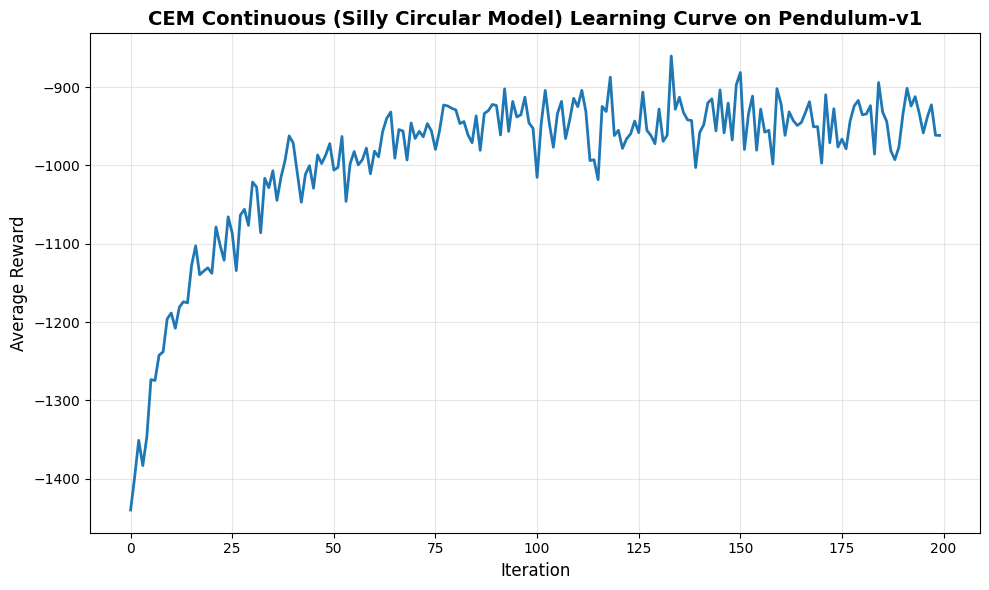

Initial average reward: -1440.03
Final average reward: -961.81
Best average reward: -860.45
Improvement: 478.21


In [113]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(reward_list, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.title('CEM Continuous (Silly Circular Model) Learning Curve on Pendulum-v1', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Initial average reward: {reward_list[0]:.2f}")
print(f"Final average reward: {reward_list[-1]:.2f}")
print(f"Best average reward: {max(reward_list):.2f}")
print(f"Improvement: {reward_list[-1] - reward_list[0]:.2f}")





 ## Save Results



 Save the results to a CSV file for later analysis.

In [ ]:
df = pd.DataFrame({"reward": reward_list})
df.to_csv("Linear_CEM_Continuous_circular.csv", index=False, header=True)

env.close()